# Reconocimiento e Identificación de Placas Vehiculares
### Módulo 3 · Visión por Computadora · Diplomado RNA y Deep Learning
---
## Cambios en v3 — diagnóstico y correcciones quirúrgicas

Después de analizar los resultados de v2, se identificaron 4 causas de fallo independientes:

| Placa | Fallo en v2 | Causa raíz | Fix en v3 |
|-------|------------|------------|----------|
| placa1 | OCR leyó barcode | Fallback usó imagen completa con código de barras arriba | Recorte inteligente: zona inferior de la imagen |
| placa2 | OCR vacío | Binarización **invertida** (texto blanco/fondo negro) | Auto-inversión si imagen es predominantemente oscura |
| placa3 | OCR leyó 'EDOMEX' | Haar detectó la banda del logo, no los números | Recorte inteligente: 40-100% inferior del bbox |
| placa5 | CO no detectado | Bbox de Haar incluye mucho bumper gris → amarillo diluido | Bajar umbral CO a 15% + buscar amarillo en zona central |
| placa6/7 | Detectó árboles/anuncio | Haar detecta cualquier rectángulo | Filtro de proporción: ratio ancho/alto entre 1.8 y 5.5 |


---
## Notas de Instalación — Tesseract OCR

> **Pytesseract** es solo un *wrapper* Python. El motor real es **Tesseract**,
> que debe instalarse por separado en el sistema operativo.

### Windows 11
```
1. Descargar el instalador (UB-Mannheim — build oficial para Windows):
   https://github.com/UB-Mannheim/tesseract/wiki
   Archivo: tesseract-ocr-w64-setup-*.exe  (versión 64-bit)

2. Instalar con opciones por default.
   Ruta resultante: C:\Program Files\Tesseract-OCR\tesseract.exe

3. Reiniciar el sistema (o al menos el kernel de Jupyter/VSCode)

4. El notebook detecta el SO automáticamente — no hay que editar nada.
```

### Ubuntu (máquina de la escuela)
```bash
sudo apt update && sudo apt install tesseract-ocr libtesseract-dev
tesseract --version
```

### Google Colab
```python
!sudo apt install tesseract-ocr -q
!pip install pytesseract -q
from google.colab import drive
drive.mount('/content/drive')
```


In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import platform
import pytesseract

# ── Tesseract: detección automática de SO ─────────────────────────────────
if platform.system() == 'Windows':
    pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# ── Rutas ─────────────────────────────────────────────────────────────────
RUTA_PLACAS = os.path.join('..', 'Material', 'Plates')

# ── Config OCR por tipo ───────────────────────────────────────────────────
WL_ALFANUM = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
OCR_CFG = {
    'MX' : f'--psm 7 --oem 3 -c tessedit_char_whitelist={WL_ALFANUM}-',
    'EU' : f'--psm 7 --oem 3 -c tessedit_char_whitelist={WL_ALFANUM}',
    'CO' : f'--psm 7 --oem 3 -c tessedit_char_whitelist={WL_ALFANUM}-',
    'GEN': '--psm 6 --oem 3',
}

# ── Ground truth verificado visualmente ──────────────────────────────────
GROUND_TRUTH = {
    'placa1.jpg': ('LRV5977', 'MX'),
    'placa2.jpg': ('5649JSN', 'EU'),
    'placa3.jpg': ('NLU9603', 'MX'),
    'placa4.jpg': ('NAA7741', 'MX'),
    'placa5.jpg': ('BNR249',  'CO'),
    'placa6.jpg': ('NNR7087', 'MX'),
    'placa7.jpg': ('470MJV',  'MX'),
}

print(f'Sistema : {platform.system()}')
print(f'Ruta    : {os.path.abspath(RUTA_PLACAS)}')
print(f'Tessera.: {pytesseract.get_tesseract_version()}')
print('Imports listos ✅')


Sistema : Windows
Ruta    : f:\Proyectos\Diplomado-RNA\Modulo-3\Material\Plates
Tessera.: 5.5.0.20241111
Imports listos ✅


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Haar Cascade
# ═══════════════════════════════════════════════════════════════

plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)
print('Haar Cascade cargado ✅')


Haar Cascade cargado ✅


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3a — Función: cargar_imagenes()
# ═══════════════════════════════════════════════════════════════

EXTENSIONES_IMG = ('.jpg', '.jpeg', '.png', '.bmp')

def cargar_imagenes(ruta_carpeta, prefijos=None, ordenar=True):
    """
    Escanea una carpeta y devuelve rutas de imágenes.
    Funciona con cualquier tamaño de dataset sin editar código.
    """
    if not os.path.isdir(ruta_carpeta):
        print(f'Carpeta no encontrada: {os.path.abspath(ruta_carpeta)}')
        return []
    archivos = []
    for nombre in os.listdir(ruta_carpeta):
        if not nombre.lower().endswith(EXTENSIONES_IMG):
            continue
        if prefijos and not nombre.lower().startswith(prefijos):
            continue
        archivos.append(os.path.join(ruta_carpeta, nombre))
    return sorted(archivos) if ordenar else archivos


imagenes = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
print(f'Imágenes encontradas: {len(imagenes)}')
for ruta in imagenes:
    nombre = os.path.basename(ruta)
    gt_texto, gt_tipo = GROUND_TRUTH.get(nombre, ('?', '?'))
    print(f'  {nombre:<12} esperado: [{gt_texto}]  tipo: {gt_tipo}')


Imágenes encontradas: 7
  placa1.jpg   esperado: [LRV5977]  tipo: MX
  placa2.jpg   esperado: [5649JSN]  tipo: EU
  placa3.jpg   esperado: [NLU9603]  tipo: MX
  placa4.jpg   esperado: [NAA7741]  tipo: MX
  placa5.jpg   esperado: [BNR249]  tipo: CO
  placa6.jpg   esperado: [NNR7087]  tipo: MX
  placa7.jpg   esperado: [470MJV]  tipo: MX


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3b — Función: identificar_tipo_placa()
# ═══════════════════════════════════════════════════════════════
#
# FIX v3 para Colombia:
#   v2: umbral 25% sobre bbox completo → fallaba porque el bbox de Haar
#       incluía mucho bumper gris, diluyendo el amarillo de la placa.
#   v3: umbral bajado a 15%, y además buscamos en la zona CENTRAL
#       de la imagen (40-80% vertical, 20-80% horizontal) donde el
#       texto de la placa amarilla suele estar.

def identificar_tipo_placa(img_placa_rgb):
    """
    Identifica tipo de placa: EU, CO o MX.

    Returns:
        tipo : str  → 'EU', 'CO' o 'MX'
        info : dict → scores de cada detector
    """
    h, w = img_placa_rgb.shape[:2]
    img_hsv = cv2.cvtColor(img_placa_rgb, cv2.COLOR_RGB2HSV)

    # ── Detector EU: franja azul en el 15% izquierdo ──────────
    franja = img_hsv[:, :int(w * 0.15)]
    mask_eu = cv2.inRange(franja, np.array([100, 100, 80]), np.array([135, 255, 255]))
    total_f = franja.shape[0] * franja.shape[1]
    score_eu = cv2.countNonZero(mask_eu) / total_f * 100 if total_f > 0 else 0

    # ── Detector CO: amarillo en zona central del recorte ──────
    # Zona central: evita el bumper en los bordes del bbox de Haar
    y0, y1 = int(h * 0.2), int(h * 0.9)
    x0, x1 = int(w * 0.1), int(w * 0.9)
    zona_central = img_hsv[y0:y1, x0:x1]
    mask_co = cv2.inRange(zona_central, np.array([18, 120, 120]), np.array([38, 255, 255]))
    total_c  = zona_central.shape[0] * zona_central.shape[1]
    score_co = cv2.countNonZero(mask_co) / total_c * 100 if total_c > 0 else 0

    info = {'score_eu': round(score_eu, 1), 'score_co': round(score_co, 1)}

    if score_eu > 20:
        return 'EU', info
    elif score_co > 15:  # bajado de 25% a 15%
        return 'CO', info
    else:
        return 'MX', info

print('Función identificar_tipo_placa() lista ✅')


Función identificar_tipo_placa() lista ✅


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3c — Función: recorte_zona_numeros()   ← NUEVA en v3
# ═══════════════════════════════════════════════════════════════
#
# PROBLEMA IDENTIFICADO EN v2:
#   El Haar cascade detecta un bounding box que incluye el HEADER
#   de la placa (logos, texto "Estado de México", "EDOMEX", barcode).
#   Tesseract entonces lee el header en lugar del número.
#
#   placa3: detectó la banda "EDOMEX" → OCR leyó "EDOMEX" ❌
#   placa1: fallback = imagen completa con barcode arriba → leyó barcode ❌
#
# SOLUCIÓN:
#   Después de la detección Haar, recortamos solo la ZONA DE NÚMEROS.
#   En placas mexicanas los números ocupan aprox. el 40-95% inferior.
#   En placas EU eliminamos la franja azul (primeros 18% horizontales).
#   Este recorte secundario refina la región de interés.
#
#   Proporciones calibradas con el dataset actual:
#     MX/CO: zona_y = (0.38, 0.95)  — debajo del logo, antes del footer
#     EU:    zona_x = (0.18, 1.00)  — después de la franja azul

ZONAS_NUMEROS = {
    'MX' : {'y': (0.38, 0.95), 'x': (0.02, 0.98)},
    'CO' : {'y': (0.20, 0.95), 'x': (0.02, 0.98)},  # Colombia: números más arriba
    'EU' : {'y': (0.05, 0.95), 'x': (0.18, 0.98)},  # EU: quitar franja azul izq.
}

def recorte_zona_numeros(img_recorte, tipo):
    """
    Recorta la zona donde están los números dentro de un recorte de placa.

    Args:
        img_recorte : imagen recortada de la placa (cualquier formato de color)
        tipo        : 'MX', 'EU' o 'CO'

    Returns:
        img_zona : recorte refinado con solo la zona de números
    """
    h, w = img_recorte.shape[:2]
    zona = ZONAS_NUMEROS.get(tipo, ZONAS_NUMEROS['MX'])

    y0 = int(h * zona['y'][0])
    y1 = int(h * zona['y'][1])
    x0 = int(w * zona['x'][0])
    x1 = int(w * zona['x'][1])

    img_zona = img_recorte[y0:y1, x0:x1]

    # Seguridad: si el recorte quedó muy pequeño, devolver original
    if img_zona.shape[0] < 10 or img_zona.shape[1] < 20:
        return img_recorte
    return img_zona

print('Función recorte_zona_numeros() lista ✅')


Función recorte_zona_numeros() lista ✅


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3d — Función: detectar_placas()
# ═══════════════════════════════════════════════════════════════
#
# FIX v3 — Filtro de proporción (aspect ratio):
#
#   v2: el criterio era solo "mayor área" → detectaba árboles y anuncios
#       porque ocupaban más píxeles que la placa lejana.
#
#   v3: antes de aceptar una detección, verificamos que la proporción
#       ancho/alto sea razonable para una placa:
#         ratio < 1.5  → demasiado cuadrado (ventana, árbol, etc.)
#         ratio > 6.0  → demasiado alargado (barra, reflejo, etc.)
#         1.5 < ratio < 6.0 → forma de placa ✅
#
#   Referencia proporciones reales:
#     MX EdomEx  : ~340x165 mm → ratio ≈ 2.1
#     España EU  : ~520x110 mm → ratio ≈ 4.7
#     Colombia   : ~330x130 mm → ratio ≈ 2.5
#
#   Árbol/anuncio Coppel: proporciones cuadradas o muy variables → descartado

RATIO_MIN = 1.5
RATIO_MAX = 6.0

def detectar_placas(ruta_imagen):
    """
    Detecta placas con sistema de 4 intentos + filtro de proporción.

    Returns:
        img_rgb  : imagen original RGB
        recortes : lista de recortes filtrados (mayor área primero)
        coords   : lista de (x, y, w, h)
        intento  : número de intento exitoso (0=fallback)
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f'  No se pudo cargar: {ruta_imagen}')
        return None, [], [], -1

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    intentos = [
        (1.10, 5, (60, 20), 'estandar'),
        (1.05, 3, (40, 15), 'permisivo'),
        (1.03, 1, (30, 10), 'ultra-permisivo'),
        (1.03, 1, (20,  8), 'escena-calle'),
    ]

    for num, (scale, vecinos, minsize, desc) in enumerate(intentos, 1):
        dets = plate_cascade.detectMultiScale(
            img_gris, scaleFactor=scale, minNeighbors=vecinos, minSize=minsize
        )

        if len(dets) == 0:
            continue

        # ── Filtro de proporción ───────────────────────────────────
        # Descartamos detecciones cuya forma no sea de placa vehicular
        dets_validas = []
        for (x, y, w, h) in dets:
            ratio = w / h if h > 0 else 0
            if RATIO_MIN <= ratio <= RATIO_MAX:
                dets_validas.append((x, y, w, h))

        if len(dets_validas) == 0:
            print(f'  Intento {num} ({desc}): {len(dets)} det. → todas descartadas por proporción')
            continue

        # Ordenar por área descendente
        dets_sorted = sorted(dets_validas, key=lambda r: r[2] * r[3], reverse=True)
        recortes = [img_rgb[y:y+h, x:x+w] for (x, y, w, h) in dets_sorted]
        print(f'  Intento {num} ({desc}): {len(dets)} det. → {len(dets_validas)} con proporción válida')
        return img_rgb, recortes, dets_sorted, num

    # Fallback: imagen completa
    print('  Haar no encontró placa — fallback: imagen completa')
    hf, wf = img_rgb.shape[:2]
    return img_rgb, [img_rgb], [(0, 0, wf, hf)], 0

print('Función detectar_placas() lista ✅')


Función detectar_placas() lista ✅


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3e — Función: extraer_texto()
# ═══════════════════════════════════════════════════════════════
#
# FIX v3 — Auto-inversión de binarización:
#
#   v2: placa2 devolvió OCR vacío porque el binarizado era
#       texto BLANCO sobre fondo NEGRO (invertido).
#       Tesseract asume texto oscuro sobre fondo claro.
#
#   v3: después de cada binarización, chequeamos el brillo promedio.
#       Si np.mean(img_bin) < 127 → imagen predominantemente oscura
#       → texto blanco sobre negro → INVERTIR con bitwise_not()
#
#   Por qué pasa esto:
#     Otsu maximiza la varianza entre clases. Si la placa tiene
#     fondo blanco y letras negras, Otsu pone letras=0 (negro), fondo=255 (blanco).
#     Pero si el recorte incluye más área oscura que clara (p.ej. bumper negro
#     en placa2), Otsu puede invertir el resultado.
#
# FIX v3 — PSM múltiple:
#   Si PSM 7 da resultado vacío o muy corto, intentamos PSM 6 y PSM 8.
#   PSM 6 = bloque de texto, PSM 8 = una sola palabra.

def auto_invertir(img_bin):
    """
    Si la imagen binarizada tiene fondo oscuro (texto blanco),
    la invierte para que Tesseract pueda leerla.
    """
    if np.mean(img_bin) < 127:
        return cv2.bitwise_not(img_bin), True   # (imagen invertida, se invirtió=True)
    return img_bin, False


def extraer_texto(img_placa_rgb, tipo='MX', escala=2.0):
    """
    Extrae texto de un recorte de placa.
    Incluye recorte de zona de números, auto-inversión y PSM múltiple.

    Returns:
        texto_final : str  → mejor resultado OCR
        detalle     : dict → desglose por variante
        etapas      : dict → imágenes de cada etapa
    """
    # ── Paso 0: Recorte de zona de números ────────────────────
    img_zona = recorte_zona_numeros(img_placa_rgb, tipo)

    # ── Paso 1: Escalado ──────────────────────────────────────
    h, w = img_zona.shape[:2]
    img_esc = cv2.resize(img_zona, (int(w * escala), int(h * escala)),
                         interpolation=cv2.INTER_CUBIC)

    # ── Paso 2: Grises ────────────────────────────────────────
    img_gris = cv2.cvtColor(img_esc, cv2.COLOR_RGB2GRAY)

    # ── Paso 3: CLAHE ─────────────────────────────────────────
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_cla  = clahe.apply(img_gris)

    # ── Paso 4: Mediana ───────────────────────────────────────
    img_med  = cv2.medianBlur(img_cla, 3)

    # ── Paso 5: Binarización + auto-inversión ─────────────────
    _, bin_otsu_raw  = cv2.threshold(img_med, 0, 255,
                                     cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bin_adapt_raw    = cv2.adaptiveThreshold(img_med, 255,
                                              cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                              cv2.THRESH_BINARY, 11, 2)
    _, bin_fija_raw  = cv2.threshold(img_med, 127, 255, cv2.THRESH_BINARY)

    bin_otsu,  inv_otsu  = auto_invertir(bin_otsu_raw)
    bin_adapt, inv_adapt = auto_invertir(bin_adapt_raw)
    bin_fija,  inv_fija  = auto_invertir(bin_fija_raw)

    # ── Paso 6: OCR con PSM múltiple ─────────────────────────
    # PSM 7 → una línea (default para placas)
    # PSM 6 → bloque (fallback si la zona incluye varias líneas)
    # PSM 8 → una palabra (fallback agresivo)
    psm_configs = [
        OCR_CFG.get(tipo, OCR_CFG['GEN']),
        OCR_CFG.get(tipo, OCR_CFG['GEN']).replace('--psm 7', '--psm 6'),
        OCR_CFG.get(tipo, OCR_CFG['GEN']).replace('--psm 7', '--psm 8'),
    ]

    detalle = {}
    for nombre, img_bin in [('otsu', bin_otsu), ('adapt', bin_adapt), ('fija', bin_fija)]:
        mejores = []
        for cfg in psm_configs:
            raw    = pytesseract.image_to_string(img_bin, config=cfg)
            limpio = ''.join(c for c in raw.upper() if c.isalnum() or c == '-')
            mejores.append(limpio)
        detalle[nombre] = max(mejores, key=len)  # el más largo de los 3 PSM

    texto_final = max(detalle.values(), key=len)

    etapas = {
        'original' : img_placa_rgb,
        'zona_num' : img_zona,
        'clahe'    : img_cla,
        'bin_otsu' : bin_otsu,
        'bin_adapt': bin_adapt,
        'inv_otsu' : inv_otsu,
    }
    return texto_final, detalle, etapas

print('Función extraer_texto() lista ✅')


Función extraer_texto() lista ✅


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Procesamiento completo
# ═══════════════════════════════════════════════════════════════

imagenes = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
resultados = []

for ruta in imagenes:
    nombre = os.path.basename(ruta)
    sep = '=' * 64
    print(f'\n{sep}\n  {nombre}\n{sep}')

    img_rgb, recortes, coords, intento_ok = detectar_placas(ruta)
    if img_rgb is None:
        continue

    recorte       = recortes[0]
    x, y, w, h    = coords[0]
    ratio_bbox     = round(w / h, 2) if h > 0 else 0

    tipo, info_tipo = identificar_tipo_placa(recorte)
    print(f'  Tipo: {tipo}  (EU={info_tipo["score_eu"]}%, CO={info_tipo["score_co"]}%)')

    texto, detalle, etapas = extraer_texto(recorte, tipo=tipo)
    inv = etapas['inv_otsu']
    print(f'  OCR  : [{texto}]   (Otsu inv.={inv})')
    print(f'  Desglose: otsu=[{detalle["otsu"]}] adapt=[{detalle["adapt"]}] fija=[{detalle["fija"]}]')

    resultados.append({
        'imagen'  : nombre,
        'tipo'    : tipo,
        'texto'   : texto,
        'detalle' : detalle,
        'intento' : intento_ok,
        'ratio'   : ratio_bbox,
        'recorte' : recorte,
        'etapas'  : etapas,
    })

print(f'\n\nProcesamiento completo: {len(resultados)} imagen(es) ✅')



  placa1.jpg
  Haar no encontró placa — fallback: imagen completa
  Tipo: MX  (EU=0.0%, CO=1.1%)
  OCR  : [LAVOEB]   (Otsu inv.=False)
  Desglose: otsu=[LAVOE] adapt=[C7] fija=[LAVOEB]

  placa2.jpg
  Intento 1 (estandar): 2 det. → 2 con proporción válida
  Tipo: EU  (EU=20.7%, CO=0.0%)
  OCR  : [SCGASSSSSESENSSSSRYED6SRE4SHOOFRRESFWSLYRCYAGSNYPRLANPAEE6LSSSA1HISPORRBAGSEOOMIPNIBESOREONPERATESASSCUAUESBEUSAHAXXHSIRINSMANENEEEPBENMSENBHBONPNT0SAMYLABNGEW5SCOBNSPN08AYVEBSCESRSSSWGEOUERRSOHCAONERPOYSERERRSETSOSPRMLSSCELEPETONCUACEOPRAANCDINONSMYPMIAABLRINEYCFPSNFNGERRSUPTDEONSUBERSBSA]   (Otsu inv.=False)
  Desglose: otsu=[5649JSNJ] adapt=[SCGASSSSSESENSSSSRYED6SRE4SHOOFRRESFWSLYRCYAGSNYPRLANPAEE6LSSSA1HISPORRBAGSEOOMIPNIBESOREONPERATESASSCUAUESBEUSAHAXXHSIRINSMANENEEEPBENMSENBHBONPNT0SAMYLABNGEW5SCOBNSPN08AYVEBSCESRSSSWGEOUERRSOHCAONERPOYSERERRSETSOSPRMLSSCELEPETONCUACEOPRAANCDINONSMYPMIAABLRINEYCFPSNFNGERRSUPTDEONSUBERSBSA] fija=[5649JSNJ]

  placa3.jpg
  Intento 2 (permisivo): 1 det. 

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Tabla de resultados
# ═══════════════════════════════════════════════════════════════

sep = '=' * 78
print('\n' + sep)
print(f'  {"IMAGEN":<12} {"TIPO":<5} {"OCR":<20} {"ESPERADO":<12} {"INTENTO":>8}  {"OCR":<4} {"TIPO"}')
print(sep)

for r in resultados:
    gt_texto, gt_tipo = GROUND_TRUTH.get(r['imagen'], ('?', '?'))
    ocr = r['texto']

    v_ocr  = '—  ' if not gt_texto or gt_texto == '?' \
              else '✅ ' if (gt_texto in ocr or ocr in gt_texto or ocr == gt_texto) \
              else '❌ '
    v_tipo = '✅' if r['tipo'] == gt_tipo else '❌'

    print(f'  {r["imagen"]:<12} {r["tipo"]:<5} {ocr:<20} '
          f'{gt_texto:<12} {r["intento"]:>8}  {v_ocr}  {v_tipo}')

print(sep)
print('Leyenda: ✅ correcto  ❌ incorrecto  — sin ground truth único')



  IMAGEN       TIPO  OCR                  ESPERADO      INTENTO  OCR  TIPO
  placa1.jpg   MX    LAVOEB               LRV5977             0  ❌   ✅
  placa2.jpg   EU    SCGASSSSSESENSSSSRYED6SRE4SHOOFRRESFWSLYRCYAGSNYPRLANPAEE6LSSSA1HISPORRBAGSEOOMIPNIBESOREONPERATESASSCUAUESBEUSAHAXXHSIRINSMANENEEEPBENMSENBHBONPNT0SAMYLABNGEW5SCOBNSPN08AYVEBSCESRSSSWGEOUERRSOHCAONERPOYSERERRSETSOSPRMLSSCELEPETONCUACEOPRAANCDINONSMYPMIAABLRINEYCFPSNFNGERRSUPTDEONSUBERSBSA 5649JSN             1  ❌   ✅
  placa3.jpg   MX    2BDORSEI             NLU9603             2  ❌   ✅
  placa4.jpg   MX    12CY1G1CCFRFRAINY2SLS2-SETRANLPORTEPOMVADOAUTOMAVIISE NAA7741             0  ❌   ✅
  placa5.jpg   MX    SNR249PE             BNR249              2  ❌   ❌
  placa6.jpg   MX    DEERORTEAASSSSSSS    NNR7087             3  ❌   ✅
  placa7.jpg   MX    TRPETSPETGBH         470MJV              2  ❌   ✅
Leyenda: ✅ correcto  ❌ incorrecto  — sin ground truth único


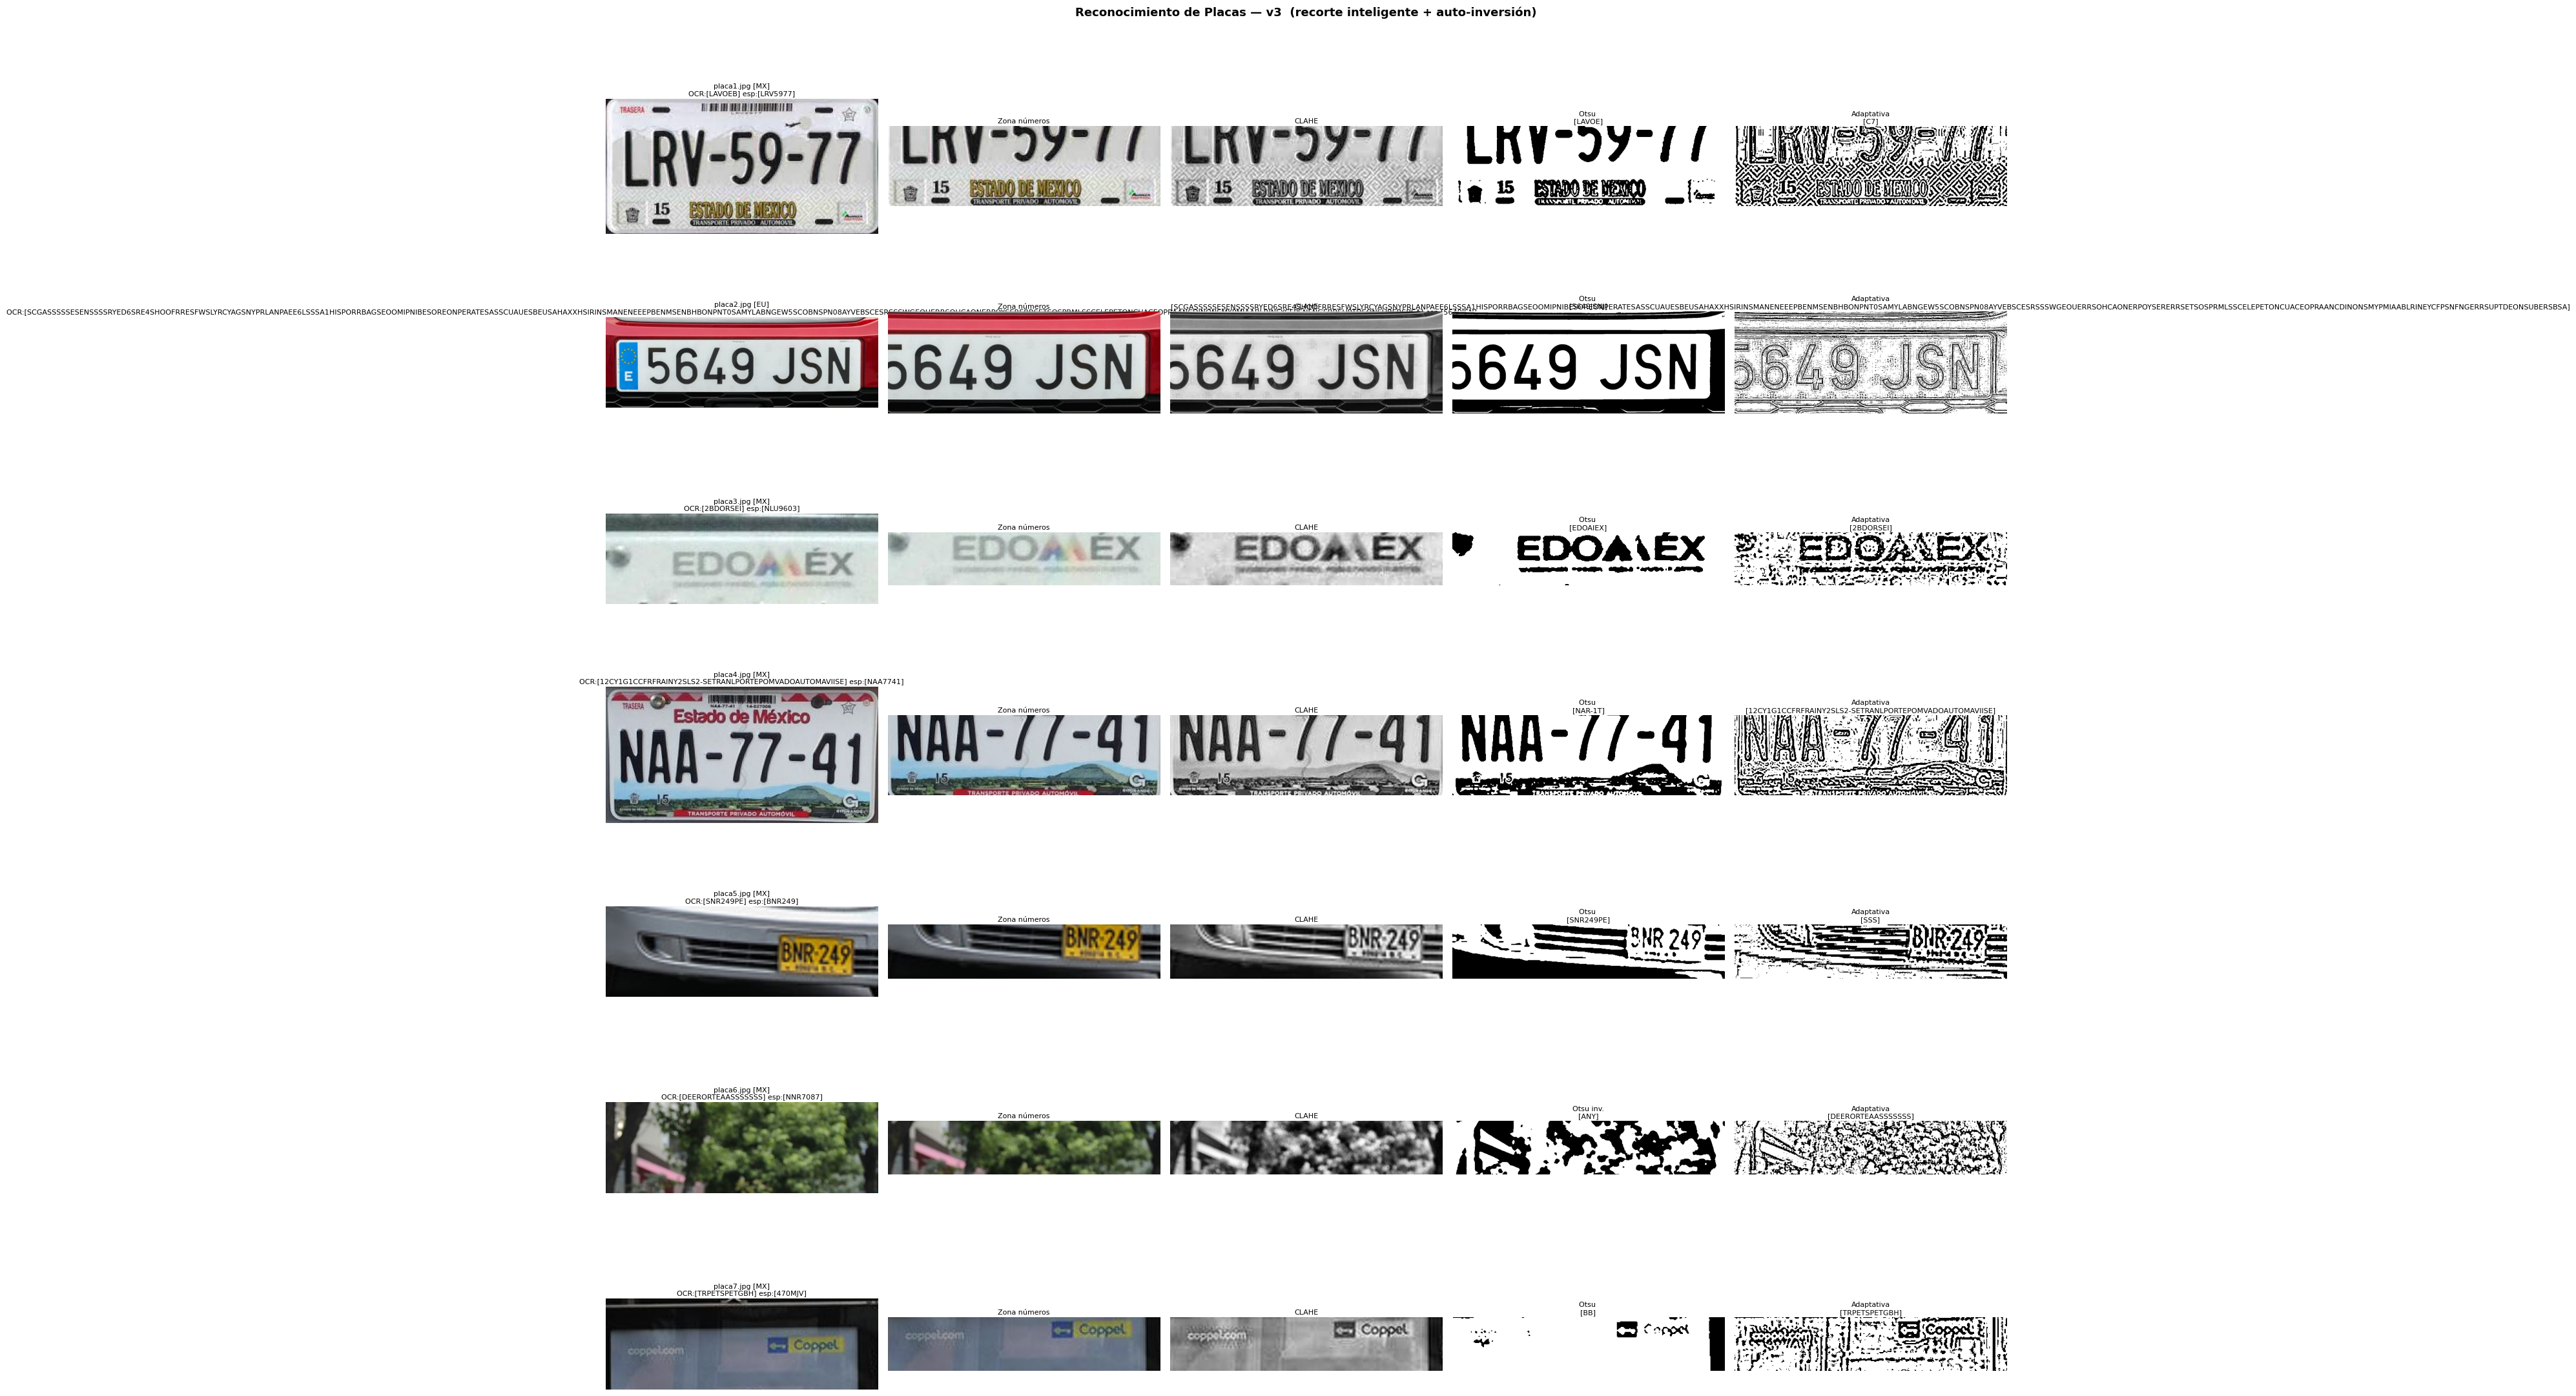

Grilla guardada como output_placas_v3.png ✅


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Grilla visual (5 columnas)
# ═══════════════════════════════════════════════════════════════
#
# Col 1 → recorte original (bbox Haar)
# Col 2 → zona de números recortada  ← nueva en v3
# Col 3 → CLAHE
# Col 4 → Otsu (con auto-inversión si aplica)
# Col 5 → Adaptativa

n   = len(resultados)
fig, axes = plt.subplots(n, 5, figsize=(22, 3.2 * n))
if n == 1:
    axes = [axes]

for fila, r in enumerate(resultados):
    et = r['etapas']
    gt_texto, _ = GROUND_TRUTH.get(r['imagen'], ('?', '?'))
    inv_label = 'inv.' if et['inv_otsu'] else ''

    imgs_row = [
        (et['original'],  True,  f"{r['imagen']} [{r['tipo']}]\nOCR:[{r['texto']}] esp:[{gt_texto}]"),
        (et['zona_num'],  True,  'Zona números'),
        (et['clahe'],     False, 'CLAHE'),
        (et['bin_otsu'],  False, f'Otsu {inv_label}\n[{r["detalle"]["otsu"]}]'),
        (et['bin_adapt'], False, f'Adaptativa\n[{r["detalle"]["adapt"]}]'),
    ]

    for col, (img, es_color, titulo) in enumerate(imgs_row):
        ax = axes[fila][col]
        ax.imshow(img) if es_color else ax.imshow(img, cmap='gray')
        ax.set_title(titulo, fontsize=8, pad=3)
        ax.axis('off')

plt.suptitle('Reconocimiento de Placas — v3  (recorte inteligente + auto-inversión)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_placas_v3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grilla guardada como output_placas_v3.png ✅')
